# VAE (Variational AutoEncoder) - 초급용
## 이미지 생성 AI 입문

### 학습 목표
- VAE가 어떻게 이미지를 생성하는지 이해하기
- Encoder와 Decoder의 역할 알아보기
- 잠재 공간(Latent Space)의 개념 체험하기


## STEP 1️⃣ : 필요한 라이브러리 불러오기

딥러닝을 위한 기본 도구들을 가져옵니다.

In [1]:
# !sudo apt-get install -y fonts-nanum* | tail -n 1
# !sudo fc-cache -fv
# !rm -rf ~/.cache/matplotlib

In [ ]:
# 필요 라이브러리 설치

# !pip install torchviz | tail -n 1

런타임 다시 시작

In [2]:
# PyTorch: 딥러닝 프레임워크
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 데이터셋 관련
from torchvision import datasets, transforms

# 시각화 도구
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch 버전: {torch.__version__}")

PyTorch 버전: 2.10.0+cu130


In [3]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [4]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## STEP 2️⃣ : 기본 설정하기

학습에 필요한 기본값들을 정해줍니다.

In [5]:
# GPU가 있으면 사용하고, 없으면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")

# 하이퍼파라미터 (학습 설정값)
batch_size = 128        # 한 번에 처리할 이미지 개수
learning_rate = 0.001   # 학습 속도
num_epochs = 10         # 전체 데이터를 몇 번 반복할지
latent_dim = 20         # 잠재 공간의 차원 (압축된 정보의 크기)

print(f"\n배치 크기: {batch_size}")
print(f"학습률: {learning_rate}")
print(f"에포크 수: {num_epochs}")
print(f"잠재 차원: {latent_dim}")

사용 중인 디바이스: cuda

배치 크기: 128
학습률: 0.001
에포크 수: 10
잠재 차원: 20


## STEP 3️⃣ : 데이터 준비하기 (MNIST 손글씨)

0~9 숫자 손글씨 이미지를 다운로드하고 준비합니다.

In [6]:
# 이미지 전처리 방법 정의
# ToTensor(): 이미지를 숫자 배열로 변환 (0~1 사이 값)
transform = transforms.ToTensor()

# MNIST 데이터셋 다운로드
train_dataset = datasets.MNIST(
    root='강의_7기_AI응용_7차시_이미지 생성형_GAN_VAE/mnist',          # 데이터 저장 위치
    train=True,             # 학습용 데이터
    download=True,          # 자동 다운로드
    transform=transform     # 전처리 적용
)

# 데이터를 배치 단위로 불러올 준비
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True            # 데이터를 섞어서 학습
)

print(f"총 학습 이미지 수: {len(train_dataset)}장")
print(f"이미지 크기: 28 x 28 픽셀")

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.70MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 152kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.12MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.06MB/s]

총 학습 이미지 수: 60000장
이미지 크기: 28 x 28 픽셀


## STEP 4️⃣ : 샘플 이미지 확인하기

실제 데이터가 어떻게 생겼는지 확인해봅시다.

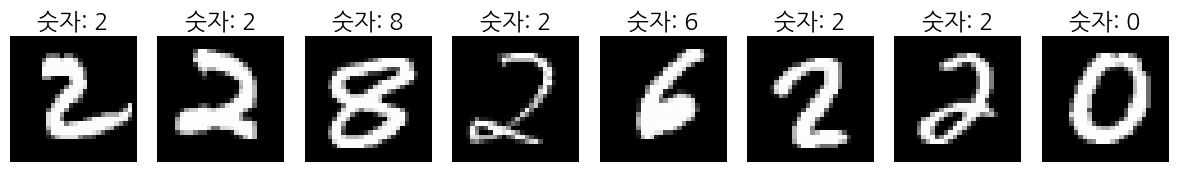

이미지 형태: torch.Size([1, 28, 28])


In [7]:
# 첫 번째 배치의 이미지 가져오기
sample_images, sample_labels = next(iter(train_loader))

# 8개 이미지 시각화
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    # 이미지는 [채널, 높이, 너비] 형태이므로 [0]으로 채널 제거
    plt.imshow(sample_images[i][0], cmap='gray')
    plt.title(f"숫자: {sample_labels[i]}")
    plt.axis('off')  # 축 숨기기
plt.tight_layout()
plt.show()

print(f"이미지 형태: {sample_images[0].shape}")  # [1, 28, 28]

## STEP 5️⃣ : Encoder (인코더) 만들기

**인코더의 역할**: 이미지를 작은 정보(잠재 변수)로 압축하기

이미지(28x28=784차원) → 작은 숫자들(20차원)

In [8]:
# Encoder 네트워크 구조
# 입력: 784차원 (28x28 이미지를 1차원으로 펼친 것)
# 출력: 평균(mu)과 분산(logvar) 각각 20차원

encoder = nn.Sequential(
    # 첫 번째 층: 784 → 400
    nn.Linear(784, 400),
    nn.ReLU(),  # 활성화 함수 (음수를 0으로 만듦)

    # 두 번째 층: 400 → 200
    nn.Linear(400, 200),
    nn.ReLU()
)

# 잠재 공간의 평균을 출력하는 층
fc_mu = nn.Linear(200, latent_dim)

# 잠재 공간의 분산(로그값)을 출력하는 층
fc_logvar = nn.Linear(200, latent_dim)

# 모델을 GPU/CPU로 이동
encoder = encoder.to(device)
fc_mu = fc_mu.to(device)
fc_logvar = fc_logvar.to(device)

print(f"입력 크기: 784 → 출력 크기: {latent_dim} (평균), {latent_dim} (분산)")

입력 크기: 784 → 출력 크기: 20 (평균), 20 (분산)


## STEP 6️⃣ : Decoder (디코더) 만들기

**디코더의 역할**: 작은 정보에서 이미지를 다시 복원하기

작은 숫자들(20차원) → 이미지(28x28=784차원)

In [9]:
# Decoder 네트워크 구조
# 입력: 20차원 (잠재 변수)
# 출력: 784차원 (복원된 이미지)

decoder = nn.Sequential(
    # 첫 번째 층: 20 → 200
    nn.Linear(latent_dim, 200),
    nn.ReLU(),

    # 두 번째 층: 200 → 400
    nn.Linear(200, 400),
    nn.ReLU(),

    # 세 번째 층: 400 → 784
    nn.Linear(400, 784),
    nn.Sigmoid()  # 출력을 0~1 사이로 만들기 (이미지 픽셀값)
)

decoder = decoder.to(device)

print(f"입력 크기: {latent_dim} → 출력 크기: 784")

입력 크기: 20 → 출력 크기: 784


## STEP 7️⃣ : Reparameterization Trick (재매개변수화)

**핵심 아이디어**: 평균과 분산에서 랜덤하게 샘플링하기

z = μ + σ × ε (ε는 표준정규분포에서 뽑은 랜덤 값)

In [9]:
# 재매개변수화 함수
# 입력: mu (평균), logvar (로그 분산)
# 출력: 샘플링된 잠재 변수 z

print("이 기법을 사용하면 역전파(backpropagation)가 가능해집니다.")

이 기법을 사용하면 역전파(backpropagation)가 가능해집니다.


## STEP 8️⃣ : Loss 함수 이해하기

VAE는 2가지 손실을 합친 것을 사용합니다:

1. **Reconstruction Loss**: 원본과 복원 이미지가 얼마나 비슷한가?
2. **KL Divergence**: 잠재 공간이 정규분포를 따르는가?

In [10]:
print("VAE Loss 구성")
print("="*50)
print("1. Reconstruction Loss (BCE)")
print("   → 원본 이미지와 복원 이미지의 차이")
print("   → 작을수록 좋음")
print()
print("2. KL Divergence")
print("   → 잠재 공간이 표준정규분포에서 얼마나 벗어났는지")
print("   → 작을수록 좋음 (분포가 정규분포에 가까움)")
print()
print("Total Loss = Reconstruction Loss + KL Divergence")

VAE Loss 구성
1. Reconstruction Loss (BCE)
   → 원본 이미지와 복원 이미지의 차이
   → 작을수록 좋음

2. KL Divergence
   → 잠재 공간이 표준정규분포에서 얼마나 벗어났는지
   → 작을수록 좋음 (분포가 정규분포에 가까움)

Total Loss = Reconstruction Loss + KL Divergence


## STEP 9️⃣ : Optimizer (최적화 도구) 설정

모든 학습 가능한 파라미터를 모아서 Adam 최적화 알고리즘으로 학습합니다.

In [10]:
# 모든 파라미터를 하나의 리스트로 모으기
all_parameters = list(encoder.parameters()) + \
                 list(fc_mu.parameters()) + \
                 list(fc_logvar.parameters()) + \
                 list(decoder.parameters())

# Adam 옵티마이저 생성
optimizer = optim.Adam(all_parameters, lr=learning_rate)

print(f"총 학습 가능한 파라미터 그룹 수: {len(list(encoder.parameters()) + list(fc_mu.parameters()) + list(fc_logvar.parameters()) + list(decoder.parameters()))}개")

총 학습 가능한 파라미터 그룹 수: 14개


## STEP 🔟 : 학습 시작하기! (메인 훈련 루프)

이제 실제로 VAE를 학습시킵니다.

In [11]:
# 학습 모드로 전환
encoder.train()
decoder.train()
fc_mu.train()
fc_logvar.train()

# 손실값 기록용 리스트
loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0  # 이번 에포크의 총 손실

    for batch_idx, (images, _) in enumerate(train_loader):
        # 1. 데이터 준비
        images = images.to(device)
        batch_size_current = images.size(0)

        # 이미지를 1차원으로 펼치기: [batch, 1, 28, 28] → [batch, 784]
        images_flat = images.view(batch_size_current, -1)

        # 2. Forward Pass (순전파)
        # Encoder를 통과시켜 잠재 변수의 평균과 분산 얻기
        hidden = encoder(images_flat)
        mu = fc_mu(hidden)
        logvar = fc_logvar(hidden)

        # Reparameterization: z = mu + std * epsilon
        std = torch.exp(0.5 * logvar)  # 로그 분산을 표준편차로 변환
        epsilon = torch.randn_like(std)  # 표준정규분포에서 샘플링
        z = mu + std * epsilon  # 잠재 변수

        # Decoder를 통과시켜 이미지 복원
        reconstructed = decoder(z)

        # 3. Loss 계산
        # Reconstruction Loss (Binary Cross Entropy)
        recon_loss = nn.functional.binary_cross_entropy(
            reconstructed, images_flat, reduction='sum'
        )

        # KL Divergence Loss
        # 공식: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # Total Loss
        loss = recon_loss + kl_loss

        # 4. Backward Pass (역전파) 및 파라미터 업데이트
        optimizer.zero_grad()  # 기울기 초기화
        loss.backward()  # 역전파
        optimizer.step()  # 파라미터 업데이트

        epoch_loss += loss.item()

    # 에포크별 평균 손실 계산
    avg_loss = epoch_loss / len(train_dataset)
    loss_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")


Epoch [1/10] - Loss: 180.1837
Epoch [2/10] - Loss: 130.2625
Epoch [3/10] - Loss: 118.4410
Epoch [4/10] - Loss: 113.6427
Epoch [5/10] - Loss: 110.9225
Epoch [6/10] - Loss: 109.0022
Epoch [7/10] - Loss: 107.6207
Epoch [8/10] - Loss: 106.5171
Epoch [9/10] - Loss: 105.5913
Epoch [10/10] - Loss: 104.8752


## STEP 1️⃣1️⃣ : 학습 과정 시각화하기

Loss가 점점 줄어드는 것을 확인해봅시다.

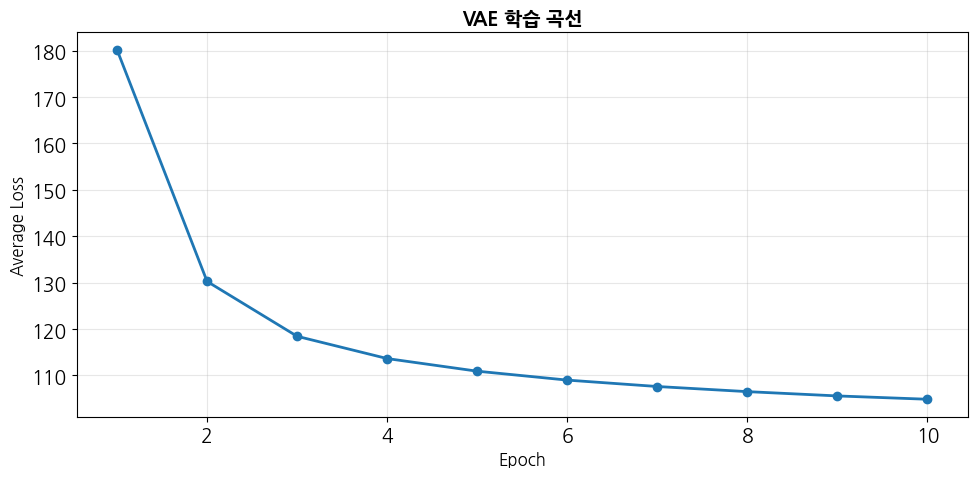

초기 Loss: 180.1837
최종 Loss: 104.8752
개선율: 41.80%


In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), loss_history, marker='o', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('VAE 학습 곡선', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"초기 Loss: {loss_history[0]:.4f}")
print(f"최종 Loss: {loss_history[-1]:.4f}")
print(f"개선율: {(1 - loss_history[-1]/loss_history[0])*100:.2f}%")

## STEP 1️⃣2️⃣ : 이미지 복원 결과 확인하기

원본 이미지와 VAE가 복원한 이미지를 비교해봅시다.

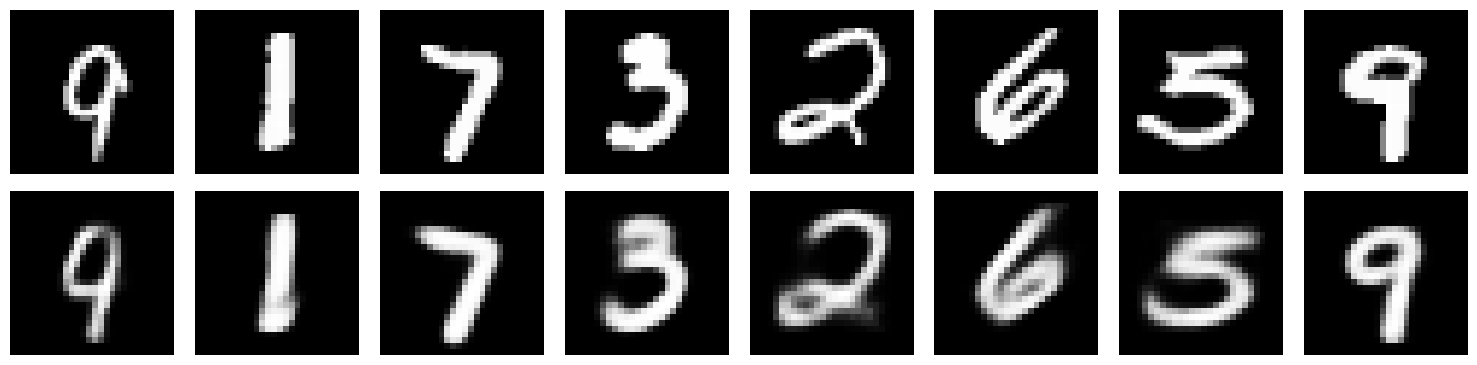

위: 원본 이미지
아래: VAE가 복원한 이미지


In [13]:
# 평가 모드로 전환 (학습 안 함)
encoder.eval()
decoder.eval()
fc_mu.eval()
fc_logvar.eval()

with torch.no_grad():  # 기울기 계산 안 함
    # 테스트 이미지 가져오기
    test_images, _ = next(iter(train_loader))
    test_images = test_images.to(device)
    test_images_flat = test_images.view(test_images.size(0), -1)

    # Encoder → Decoder 거쳐서 복원
    hidden = encoder(test_images_flat)
    mu = fc_mu(hidden)
    logvar = fc_logvar(hidden)

    std = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(std)
    z = mu + std * epsilon

    reconstructed = decoder(z)

    # CPU로 이동 및 이미지 형태로 변환
    test_images = test_images.cpu()
    reconstructed = reconstructed.view(-1, 1, 28, 28).cpu()

# 원본과 복원 이미지 비교
n_samples = 8
plt.figure(figsize=(15, 4))

for i in range(n_samples):
    # 원본 이미지
    plt.subplot(2, n_samples, i+1)
    plt.imshow(test_images[i][0], cmap='gray')
    if i == 0:
        plt.ylabel('원본', fontsize=12, fontweight='bold')
    plt.axis('off')

    # 복원 이미지
    plt.subplot(2, n_samples, n_samples+i+1)
    plt.imshow(reconstructed[i][0], cmap='gray')
    if i == 0:
        plt.ylabel('복원', fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("위: 원본 이미지")
print("아래: VAE가 복원한 이미지")

## STEP 1️⃣3️⃣ : 새로운 이미지 생성하기! 🎨

**이것이 VAE의 핵심!**

랜덤한 잠재 변수에서 완전히 새로운 이미지를 만들어냅니다.

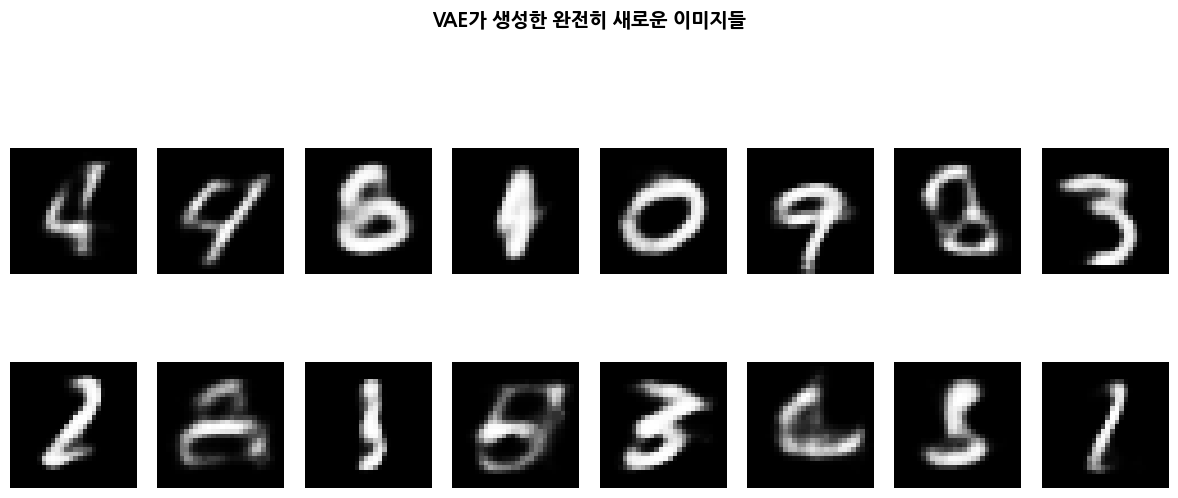

In [14]:
decoder.eval()

with torch.no_grad():
    # 표준정규분포에서 랜덤 샘플링 (잠재 변수 생성)
    random_z = torch.randn(16, latent_dim).to(device)

    # Decoder를 통해 이미지 생성
    generated_images = decoder(random_z)
    generated_images = generated_images.view(-1, 1, 28, 28).cpu()

# 생성된 이미지 시각화
plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle('VAE가 생성한 완전히 새로운 이미지들', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 1️⃣4️⃣ : 잠재 공간 탐험하기 (2D 시각화)

잠재 공간의 2개 차원만 조절하면서 어떤 이미지가 나오는지 확인해봅시다.

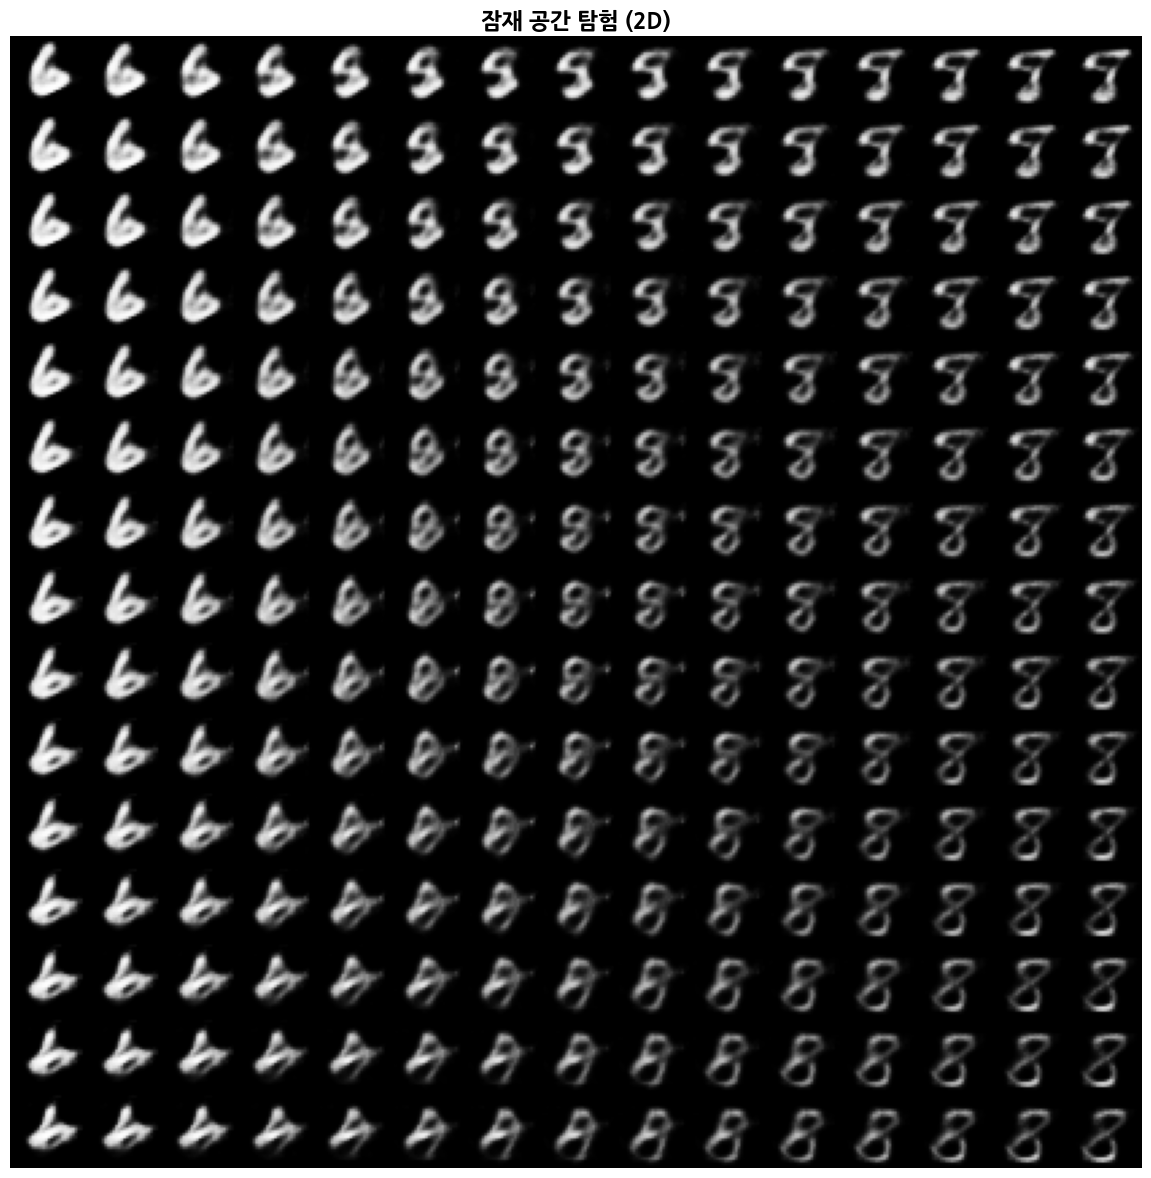

잠재 공간의 위치가 연속적으로 변할 때 이미지도 자연스럽게 변합니다!
이것이 VAE가 '분포'를 학습했다는 증거입니다.


In [15]:
decoder.eval()

# 잠재 공간의 범위 설정 (-3 ~ 3)
n = 15  # 15x15 그리드
grid_range = 3

# 결과 이미지를 담을 큰 캔버스
canvas = np.zeros((28 * n, 28 * n))

with torch.no_grad():
    for i, z1 in enumerate(np.linspace(-grid_range, grid_range, n)):
        for j, z2 in enumerate(np.linspace(-grid_range, grid_range, n)):
            # 잠재 벡터 생성 (처음 2개 차원만 조절, 나머지는 0)
            z = torch.zeros(1, latent_dim).to(device)
            z[0, 0] = z1
            z[0, 1] = z2

            # 이미지 생성
            generated = decoder(z)
            img = generated.view(28, 28).cpu().numpy()

            # 캔버스에 배치
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img

# 시각화
plt.figure(figsize=(12, 12))
plt.imshow(canvas, cmap='gray')
plt.title('잠재 공간 탐험 (2D)', fontsize=16, fontweight='bold')
plt.xlabel('잠재 차원 2', fontsize=12)
plt.ylabel('잠재 차원 1', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

print("잠재 공간의 위치가 연속적으로 변할 때 이미지도 자연스럽게 변합니다!")
print("이것이 VAE가 '분포'를 학습했다는 증거입니다.")

## 학습 마무리

###  오늘 배운 내용

1. **VAE의 구조**
   - Encoder: 이미지 → 잠재 변수 (압축)
   - Decoder: 잠재 변수 → 이미지 (복원/생성)

2. **VAE의 학습 원리**
   - Reconstruction Loss: 이미지 복원 잘하기
   - KL Divergence: 잠재 공간을 정규분포로 만들기

3. **VAE의 특별한 점**
   - 완전히 새로운 이미지 생성 가능
   - 잠재 공간이 연속적 (부드러운 전환)
